<a href="https://colab.research.google.com/github/hle369518-dotcom/TriTueNhantao/blob/main/BTTL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#bai4
# ĐỌC FILE MA TRẬN KỀ

def readGraph(filename):
    G = []

    with open(filename, "r") as f:
        for line in f:
            row = list(map(int, line.split()))
            G.append(row)

    return G


# TÍNH BẬC CÁC ĐỈNH

def degreeGraph(G):
    degree = []

    for i in range(len(G)):
        deg = sum(G[i])
        degree.append(deg)

    return degree


# SẮP XẾP ĐỈNH THEO BẬC GIẢM DẦN

def sortNode(node, degree):
    sortedNode = []
    indexs = []

    for i in range(len(degree)):
        _max = -1
        idx = -1

        for j in range(len(degree)):
            if j not in indexs:
                if degree[j] > _max:
                    _max = degree[j]
                    idx = j

        indexs.append(idx)
        sortedNode.append(node[idx])

    return sortedNode


# THUẬT TOÁN TÔ MÀU

def graphColoring(G):

    n = len(G)

    node = []

    for i in range(n):
        node.append(i)

    degree = degreeGraph(G)

    # Danh sách màu
    colors = ["Blue", "Red", "Yellow", "Green", "Orange", "Pink"]

    # Mỗi đỉnh có thể dùng tất cả màu ban đầu
    colorDict = {}

    for i in range(n):
        colorDict[node[i]] = colors.copy()

    # Sắp xếp đỉnh theo bậc giảm dần
    sortedNode = sortNode(node, degree)

    theSolution = {}

    # Tô màu
    for n in sortedNode:

        setTheColor = colorDict[n]

        theSolution[n] = setTheColor[0]

        adjacentNode = G[n]

        for j in range(len(adjacentNode)):

            if adjacentNode[j] == 1:

                if setTheColor[0] in colorDict[node[j]]:
                    colorDict[node[j]].remove(setTheColor[0])

    return theSolution


# IN KẾT QUẢ
G = readGraph("graph.txt")

result = graphColoring(G)

print("KET QUA TO MAU DO THI:\n")

for dinh, mau in sorted(result.items()):
    print("Dinh", dinh, "->", mau)

In [2]:
#bai4
from itertools import permutations


def travelingSalesmanProblem(graph, start):

    n = len(graph)

    vertex = []

    for i in range(n):
        if i != start:
            vertex.append(i)

    minPath = float('inf')
    bestPath = []

    nextPermutation = permutations(vertex)

    for path in nextPermutation:

        currentWeight = 0

        k = start

        tempPath = [start]

        for j in path:
            currentWeight += graph[k][j]
            k = j
            tempPath.append(j)

        currentWeight += graph[k][start]
        tempPath.append(start)

        if currentWeight < minPath:
            minPath = currentWeight
            bestPath = tempPath

    return minPath, bestPath


# =========================
# MA TRAN CHI PHI
# =========================

graph = [
    [0, 10, 15, 20],
    [10, 0, 35, 25],
    [15, 35, 0, 30],
    [20, 25, 30, 0]
]

cost, path = travelingSalesmanProblem(graph, 0)

print("Chi phi nho nhat:", cost)

print("Duong di:")

for city in path:
    print(city, end=" ")

Chi phi nho nhat: 80
Duong di:
0 1 3 2 0 

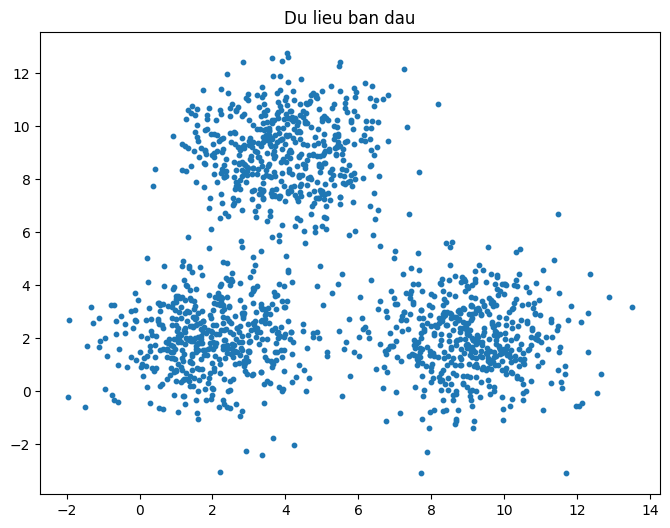

So lan lap: 5

Tam cum:
[[9.04127093 2.01231506]
 [1.99402283 2.02317579]
 [3.96731763 9.03761422]]


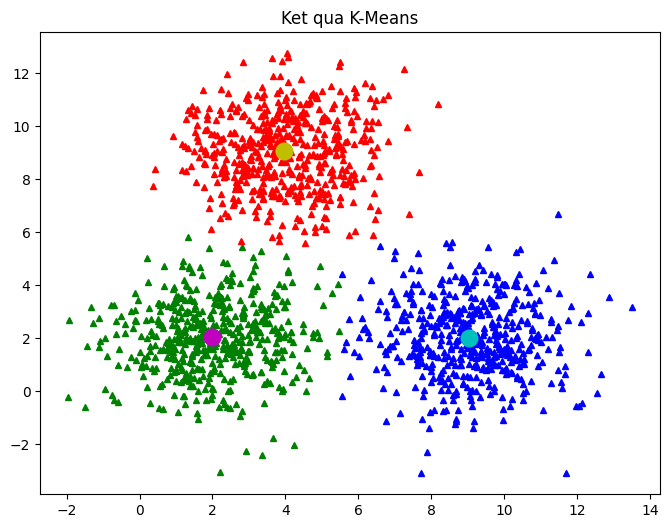

In [3]:
#bai5
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# =========================
# TẠO DỮ LIỆU
# =========================

means = [[2, 2], [9, 2], [4, 9]]
cov = [[2, 0], [0, 2]]

n_samples = 500
n_cluster = 3

X0 = np.random.multivariate_normal(means[0], cov, n_samples)
X1 = np.random.multivariate_normal(means[1], cov, n_samples)
X2 = np.random.multivariate_normal(means[2], cov, n_samples)

X = np.concatenate((X0, X1, X2), axis=0)

# =========================
# HIỂN THỊ DỮ LIỆU
# =========================

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], s=10)
plt.title("Du lieu ban dau")
plt.show()


# =========================
# KHỞI TẠO TÂM CỤM
# =========================

def kmeans_init_centers(X, n_cluster):
    return X[np.random.choice(X.shape[0], n_cluster, replace=False)]


# =========================
# GÁN NHÃN CHO DỮ LIỆU
# =========================

def kmeans_predict_labels(X, centers):

    D = cdist(X, centers)

    return np.argmin(D, axis=1)


# =========================
# CẬP NHẬT TÂM CỤM
# =========================

def kmeans_update_centers(X, labels, n_cluster):

    centers = np.zeros((n_cluster, X.shape[1]))

    for k in range(n_cluster):

        Xk = X[labels == k, :]

        centers[k,:] = np.mean(Xk, axis=0)

    return centers


# =========================
# KIỂM TRA HỘI TỤ
# =========================

def kmeans_has_converged(centers, new_centers):

    return set([tuple(a) for a in centers]) == \
           set([tuple(a) for a in new_centers])


# =========================
# HIỂN THỊ KẾT QUẢ
# =========================

def kmeans_visualize(X, centers, labels, n_cluster, title):

    colors = ['b', 'g', 'r', 'c', 'm', 'y']

    plt.figure(figsize=(8,6))

    for i in range(n_cluster):

        data = X[labels == i]

        plt.plot(data[:,0], data[:,1],
                 colors[i] + '^',
                 markersize=4)

        plt.plot(centers[i][0],
                 centers[i][1],
                 colors[i+3] + 'o',
                 markersize=12)

    plt.title(title)
    plt.show()


# =========================
# THUẬT TOÁN KMEANS
# =========================

def kmeans(init_centers, init_labels, X, n_cluster):

    centers = init_centers
    labels = init_labels

    times = 0

    while True:

        labels = kmeans_predict_labels(X, centers)

        new_centers = kmeans_update_centers(
            X,
            labels,
            n_cluster
        )

        if kmeans_has_converged(centers, new_centers):
            break

        centers = new_centers

        times += 1

    return centers, labels, times


# =========================
# CHẠY THUẬT TOÁN
# =========================

init_centers = kmeans_init_centers(X, n_cluster)

init_labels = np.zeros(X.shape[0])

centers, labels, times = kmeans(
    init_centers,
    init_labels,
    X,
    n_cluster
)

# =========================
# IN KẾT QUẢ
# =========================

print("So lan lap:", times)

print("\nTam cum:")

print(centers)

kmeans_visualize(
    X,
    centers,
    labels,
    n_cluster,
    "Ket qua K-Means"
)

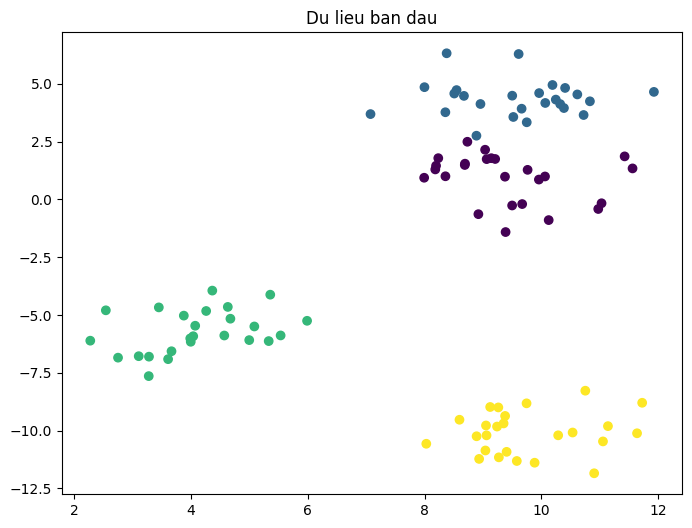

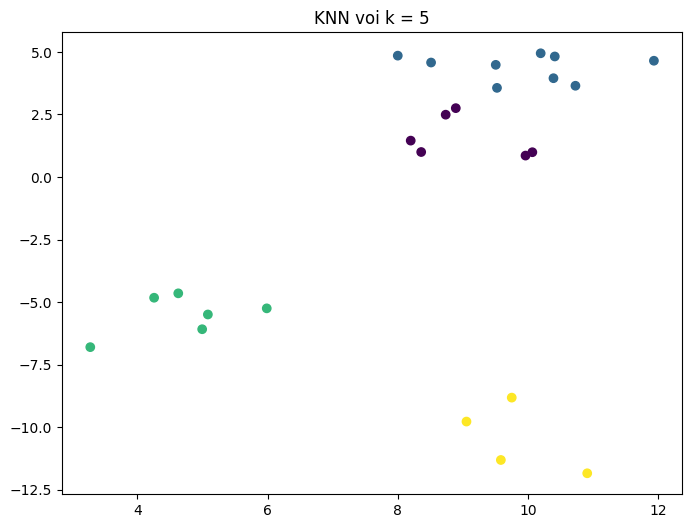

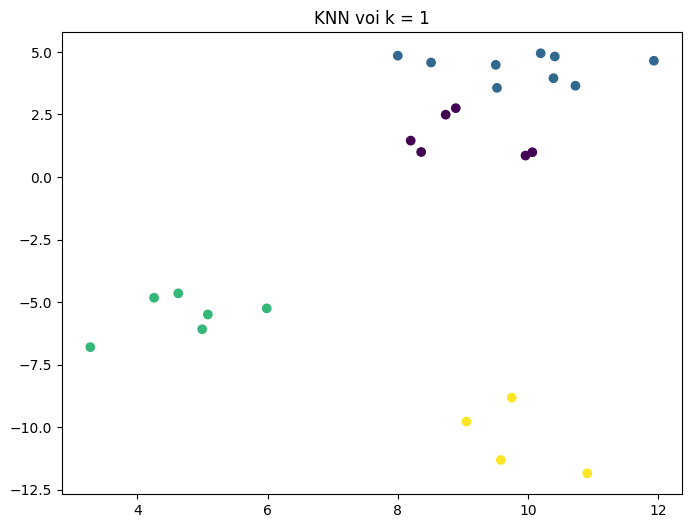

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# =========================
# TẠO DỮ LIỆU
# =========================

X, y = make_blobs(
    n_samples=100,
    n_features=2,
    centers=4,
    cluster_std=1,
    random_state=4
)

# =========================
# HIỂN THỊ DỮ LIỆU
# =========================

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Du lieu ban dau")
plt.show()

# =========================
# CHIA TRAIN/TEST
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=0
)

# =========================
# K = 5
# =========================

knn5 = KNeighborsClassifier(5)

knn5.fit(X_train, y_train)

y_pred_5 = knn5.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_5)
plt.title("KNN voi k = 5")
plt.show()


# =========================
# K = 1
# =========================

knn1 = KNeighborsClassifier(1)

knn1.fit(X_train, y_train)

y_pred_1 = knn1.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_1)
plt.title("KNN voi k = 1")
plt.show()

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# =========================
# GRID SEARCH
# =========================

knn_grid = GridSearchCV(

    estimator=KNeighborsClassifier(),

    param_grid={
        'n_neighbors': np.arange(1, 10)
    },

    cv=5
)

knn_grid.fit(X, y)

print("K tot nhat:")

print(knn_grid.best_params_)
import numpy as np

def KNN(X_train, X_test, y_train, k):

    num_test = X_test.shape[0]

    num_train = X_train.shape[0]

    y_pred = np.zeros((num_test, num_train))

    # Tính khoảng cách
    for i in range(num_test):

        for j in range(num_train):

            y_pred[i, j] = np.sqrt(
                np.sum(
                    np.power(
                        X_test[i,:] - X_train[j,:],
                        2
                    )
                )
            )

    results = []

    # Sắp xếp khoảng cách
    for i in range(len(y_pred)):

        zipped = zip(y_pred[i,:], y_train)

        res = sorted(zipped, key=lambda x: x[0])

        results_topk = res[:k]

        classes = {}

        for _, j in results_topk:

            j = int(j)

            if j not in classes:
                classes[j] = 1
            else:
                classes[j] += 1

        results.append(max(classes, key=classes.get))

    return np.array(results)


# =========================
# TEST
# =========================

X, y = make_blobs(
    n_samples=500,
    n_features=2,
    centers=4,
    cluster_std=1,
    random_state=4
)

X_test = np.array([(1,3)])

results = KNN(X, X_test, y, 3)

print("Nhan du doan:")

print(results)

K tot nhat:
{'n_neighbors': np.int64(2)}
Nhan du doan:
[0]
